# Extracción de Variables Ambientales · México 2015–2024 · **v4**
**HackODS UNAM 2026** · ODS 13 · ODS 14 · ODS 15

> **v4 — Implementaciones completas para narrativa ODS 13 rigurosa:**
>
> | # | Mejora | Detalle |
> |---|--------|---------|
> | 1 | **Error code 3 resuelto** | Tareas B1/B2 usan imagen única + un solo `reduceRegions` |
> | 2 | **Memory limit resuelto** | Tarea B original dividida en B1 (vegetación+LST+ET) y B2 (precipitación). Percentiles exportados como assets GEE permanentes antes de lanzar tareas. |
> | 3 | **SST completa 2015–2024** | NOAA OISST V2.1 reemplaza MODIS Aqua (terminaba en 2022) |
> | 4 | **Gases pre-2019** | OMI/Aura para NO₂/SO₂, MOPITT para CO. Lógica fallback 2015–2018 → S5P 2019–2024 |
> | 5 | **T2m ERA5-Land** | Anomalía vs referencia 1981–2010 (estándar IPCC) |
> | 6 | **ET MOD16A2** | Evapotranspiración real — estrés hídrico invisible |
> | 7 | **Extremos climáticos** | Días LST > p95 y días precipitación > p95 (indicador ODS 13.1.1) |
> | 8 | **Anomalía precipitación** | vs climatológico CHIRPS 1981–2010 |
> | 9 | **Fuegos FIRMS/VIIRS** | Nexo deforestación–emisiones–calidad del aire |
> | 10 | **loss_anual dinámico** | Hansen GFC por año. NaN en 2024 (artefacto corregido en consolidación) |

### Nota sobre discontinuidad instrumental en gases
Los gases NO₂ y SO₂ de **2015–2018** vienen de **OMI/Aura** (~13×24 km).
Los de **2019–2024** vienen de **Sentinel-5P TROPOMI** (~3.5×5.5 km).
**No son comparables en valor absoluto.** Analizarlos siempre como dos sub-series separadas.
CO de MOPITT sí es consistente internamente a lo largo de todo el período.

In [1]:
###############################################################################
# Author:  Aldo Heraclio de la Isla | Mayra Cuellar Urbano | Juan Mario Sosa  #
# e-mail:  aldoheraclio.delaisla@fisica.uaz.edu.mx                            #
# Date:    abr/2026                                                           #
# Subject: Extracción v4 — narrativa ODS 13 completa                         #
###############################################################################

---
## Variables del dataset v4

| # | Columna | Fuente GEE | Resolución nativa | Cobertura | Tarea |
|---|---------|-----------|-------------------|-----------|-------|
| 1–3 | `year`, `longitude`, `latitude` | Malla 25 km | 25 km | 2015–2024 | Meta |
| 4 | `ONI` | NOAA CPC (offline) | anual | 2015–2024 | Consolidación |
| 5 | `sst` | `NOAA/CDR/OISST/V2_1` | 25 km | 2015–2024 | A |
| 6 | `chlor_a` | `NASA/OCEANDATA/MODIS-Aqua/L3SMI` | 4.6 km | 2015–2022 | A |
| 7 | `t2m_anomaly` | `ECMWF/ERA5_LAND/MONTHLY_AGGR` vs ref 1981–2010 | 9 km | 2015–2024 | A |
| 8 | `loss_anual` | `UMD/hansen/global_forest_change_2023_v1_11` | 30 m | 2015–2023 | A |
| 9 | `loss_acum` | Hansen GFC v1.11 | 30 m | 2015–2024 | A |
| 10 | `treecover2000` | Hansen GFC v1.11 | 30 m | 2015–2024 | A |
| 11 | `gHM` | `CSP/HM/GlobalHumanModification` | ~1 km | 2015–2024 | A |
| 12 | `fire_count` | `NASA/FIRMS/VIIRS_SNPP_NRT` | 375 m | 2015–2024 | A |
| 13 | `NDVI` | `MODIS/061/MOD13Q1` | 250 m | 2015–2024 | B1 |
| 14 | `EVI` | `MODIS/061/MOD13Q1` | 250 m | 2015–2024 | B1 |
| 15 | `LST_day` | `MODIS/061/MOD11A2` | 1 km | 2015–2024 | B1 |
| 16 | `lst_extreme_days` | `MODIS/061/MOD11A2` vs p95 asset | 1 km | 2015–2024 | B1 |
| 17 | `ET` | `MODIS/061/MOD16A2` | 500 m | 2015–2024 | B1 |
| 18 | `precipitation` | `UCSB-CHG/CHIRPS/PENTAD` | 5.6 km | 2015–2024 | B2 |
| 19 | `precip_anomaly` | CHIRPS vs climatológico 1981–2010 | 5.6 km | 2015–2024 | B2 |
| 20 | `precip_extreme_days` | CHIRPS pentadal vs p95 asset | 5.6 km | 2015–2024 | B2 |
| 21 | `NO2` / `NO2_source` | S5P (2019–2024) / OMI (2015–2018) | 3.5 km / 13 km | 2015–2024 | C |
| 22 | `CO` / `CO_source` | S5P (2019–2024) / MOPITT (2015–2018) | 7 km / 22 km | 2015–2024 | C |
| 23 | `SO2` / `SO2_source` | S5P (2019–2024) / OMI proxy (2015–2018) | 3.5 km / 13 km | 2015–2024 | C |

### Estrategia de exportación v4
- **PASO 0** (una sola vez): Exportar assets de percentiles. Esperar COMPLETED.
- **Tarea A** (~8 min/año): SST, T2m ERA5, Hansen, gHM, FIRMS
- **Tarea B1** (~8 min/año): NDVI, EVI, LST media, días extremos LST, ET
- **Tarea B2** (~6 min/año): Precipitación total, anomalía, días extremos
- **Tarea C** (~8 min/año): Gases con fallback OMI/MOPITT → S5P
- **Consolidación**: merge A + B1 + B2 + C + ONI → `master_greenbyte_v4.csv`

In [ ]:
# ── 1. Dependencias ────────────────────────────────────────────────────────────
!pip install -q geopandas xarray rioxarray

import time
import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import os

from google.colab import drive
drive.mount('/content/drive')
print('Dependencias cargadas.') # Extra

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.2 MB/s eta 0:00:00
Mounted at /content/drive
Dependencias cargadas.


In [ ]:
# ── 2. Rutas de trabajo ────────────────────────────────────────────────────────
PATH_DRIVE  = ('/content/drive/My Drive/REDES_NEURONALES_Y_MACHING_LEARNING/'
               'HackODS_UNAM/GreenByte_HackODS/Datos/datos_crudos/')
PATH_MASTER = ('/content/drive/My Drive/REDES_NEURONALES_Y_MACHING_LEARNING/'
               'HackODS_UNAM/GreenByte_HackODS/Datos/datos_procesados/') # TODO: Rutas del repo
CARPETA_GEE = 'GreenByte_HackODS'

os.makedirs(PATH_DRIVE,  exist_ok=True) # Evitar usar esto
os.makedirs(PATH_MASTER, exist_ok=True)

# Extras 
print('Setup listo') 
print(f'  Crudos     → {PATH_DRIVE}')
print(f'  Procesados → {PATH_MASTER}')

Setup listo
  Crudos     → /content/drive/My Drive/REDES_NEURONALES_Y_MACHING_LEARNING/HackODS_UNAM/GreenByte_HackODS/Datos/datos_crudos/
  Procesados → /content/drive/My Drive/REDES_NEURONALES_Y_MACHING_LEARNING/HackODS_UNAM/GreenByte_HackODS/Datos/datos_procesados/


In [4]:
# ── 3. Inicializar Google Earth Engine ─────────────────────────────────────────
MY_PROJECT_ID = 'greenbyte-hackods-unam-2026'

try:
    ee.Initialize(project=MY_PROJECT_ID)
    print(f'Earth Engine inicializado: {MY_PROJECT_ID}')
except Exception:
    ee.Authenticate()
    ee.Initialize(project=MY_PROJECT_ID)
    print(f'Earth Engine autenticado e inicializado: {MY_PROJECT_ID}')

Earth Engine autenticado e inicializado: greenbyte-hackods-unam-2026


In [5]:
# ── 4. Malla geoespacial nacional ~25 km ───────────────────────────────────────
mexico_bbox = ee.Geometry.Rectangle([-118.5, 14.5, -86.5, 32.8])

def crear_malla(area):
    proj  = ee.Projection('EPSG:4326').atScale(25000)
    cells = area.coveringGrid(proj)
    return cells.map(lambda f: f.centroid(maxError=1))

grid = crear_malla(mexico_bbox)
print(f'Malla generada — Puntos: {grid.size().getInfo():,}')

# Climatológico CHIRPS 1981–2010 (para anomalía de precipitación en Tarea B2)
precip_clim = (ee.ImageCollection('UCSB-CHG/CHIRPS/PENTAD')
                 .filterDate('1981-01-01', '2010-12-31')
                 .select('precipitation')
                 .sum()
                 .divide(30)          # promedio anual sobre 30 años
                 .rename('precip_clim'))

print('Climatológico CHIRPS calculado.')
print()
print('SIGUIENTE PASO: ejecutar la celda PASO 0 para exportar los assets.')
print('NO ejecutes las tareas A, B1, B2, C hasta que los assets estén COMPLETED.')

Malla generada — Puntos: 12,014
Climatológico CHIRPS calculado.

SIGUIENTE PASO: ejecutar la celda PASO 0 para exportar los assets.
NO ejecutes las tareas A, B1, B2, C hasta que los assets estén COMPLETED.


---
## Tarea A — SST, T2m ERA5, Hansen, gHM, Fuegos FIRMS

Ejecutar después de que los assets del PASO 0 estén COMPLETED.

In [ ]:
def launch_tarea_A(year, grid, folder):
    """
    Tarea A v6 — CORREGIDA: Clorofila real, Fuegos acumulados y Buffers costeros.
    """
    start = ee.Date.fromYMD(year, 1, 1)
    end   = ee.Date.fromYMD(year, 12, 31)

    # ── SST: NOAA OISST V2.1 ──────────────────────────────────
    # ── Sea Surface Temperature ───────────────────────────────
    sst = (ee.ImageCollection('NOAA/CDR/OISST/V2_1')
             .filterDate(start, end)
             .select('sst')
             .mean()
             .multiply(0.01)
             .rename('sst'))

    # ── Clorofila-a: ACTIVADA (MODIS Aqua L3) ──────────────────
    # Se usa mediana anual para limpiar nubes
    chlor = (ee.ImageCollection("NASA/OCEANDATA/MODIS-Aqua/L3SMI")
               .filterDate(start, end)
               .select('chlor_a')
               .median()
               .rename('chlor_a'))

    # ── T2m anomalía ERA5-Land ────────────────────────────────
    # Temperatura a 2m en 'year'
    t2m_anual = (ee.ImageCollection('ECMWF/ERA5_LAND/MONTHLY_AGGR')
                   .filterDate(start, end)
                   .select('temperature_2m')
                   .mean()
                   .subtract(273.15).rename('t2m'))

    # Temperatura a 2m de referencia
    t2m_ref = (ee.ImageCollection('ECMWF/ERA5_LAND/MONTHLY_AGGR')
                 .filterDate('1981-01-01', '2010-12-31')
                 .select('temperature_2m')
                 .mean()
                 .subtract(273.15)
                 .rename('t2m_ref'))

    t2m_anomaly = t2m_anual.subtract(t2m_ref).rename('t2m_anomaly')

    # ── Hansen GFC v1.11 ──────────────────────────────────────
    # Metricas de deforestacion
    hansen = ee.Image('UMD/hansen/global_forest_change_2023_v1_11')
    loss_anual = (hansen.select('lossyear')
                        .eq(ee.Number(year)
                        .subtract(2000))
                        .rename('loss_anual')
                        .toFloat())
    loss_acum = hansen.select('loss').rename('loss_acum').toFloat()
    treecover = hansen.select('treecover2000').rename('treecover2000').toFloat()

    # ── Huella humana global ──────────────────────────────────
    ghm = (ee.ImageCollection('CSP/HM/GlobalHumanModification').first().select('gHM').rename('gHM'))

    # ── Fuegos FIRMS: CORREGIDO (Conteo de eventos anuales) ────
    fires = (ee.ImageCollection('FIRMS')
               .filterDate(start, end)
               .select('T21')
               .count()
               .rename('fire_count'))

    # ── Imagen multibanda única ───────────────────────────────
    imagen = (sst.addBands(chlor)
                .addBands(t2m_anomaly)
                .addBands(loss_anual)
                .addBands(loss_acum)
                .addBands(treecover)
                .addBands(ghm)
                .addBands(fires))

    # REDUCCIÓN CON BUFFER DE 5KM
    # Simplificamos la geometría a 'bounds' (un cuadrado) para que sea más veloz y estable
    grid_buffered = grid.map(lambda f: f.buffer(5000).bounds())

    resultado = imagen.reduceRegions(
        collection = grid_buffered,
        reducer    = ee.Reducer.mean(),
        scale      = 1000
    )

    def add_metadata(feature):
        # 1. Obtenemos el centroide de la geometría (sea punto o buffer)
        # 2. El parámetro '1' le da un margen de error de 1 metro para evitar fallos topológicos
        punto_central = feature.geometry().centroid(1)
        coords = punto_central.coordinates()

        return feature.set({
            'longitude': coords.get(0),
            'latitude':  coords.get(1),
            'year':      year
        })

    task = ee.batch.Export.table.toDrive(
        collection  = resultado.map(add_metadata),
        description = f'greenbyte_A_{year}',
        folder      = folder,
        fileFormat  = 'CSV',
        selectors   = ['longitude', 'latitude', 'year', 'sst', 'chlor_a', 't2m_anomaly',
                       'loss_anual', 'loss_acum', 'treecover2000', 'gHM', 'fire_count']
    )
    task.start()
    return task

---
## Tarea B1 — NDVI, EVI, LST media, días extremos LST, ET

**Requiere que los assets del PASO 0 estén COMPLETED en GEE.**

Usa `lst_p95_asset` cargado desde el asset permanente, no recalculado dentro de la tarea.
Eso es lo que evita el error de memoria (User memory limit exceeded).

In [7]:
def launch_tarea_B1(year, grid, folder):
    """
    Tarea B1 v7 — CORREGIDA: MODIS v061 y Buffer Urbano para ET.
    """
    start = ee.Date.fromYMD(year, 1, 1)
    end   = ee.Date.fromYMD(year, 12, 31)

    # 1. NDVI y EVI
    def scale_veg(img): return img.multiply(0.0001)
    modis_veg = (ee.ImageCollection('MODIS/061/MOD13Q1').filterDate(start, end).filterBounds(grid)
                    .select(['NDVI', 'EVI']).map(scale_veg))
    ndvi = modis_veg.select('NDVI').median().rename('NDVI')
    evi  = modis_veg.select('EVI').median().rename('EVI')

    # 2. LST (Temperatura Superficial)
    def scale_lst(img): return img.select('LST_Day_1km').multiply(0.02)
    lst_col = (ee.ImageCollection('MODIS/061/MOD11A2').filterDate(start, end).filterBounds(grid)
                  .select('LST_Day_1km').map(scale_lst))
    lst_mean = lst_col.mean().rename('LST_day')

    # 3. ET: CORREGIDO (Versión 061 + Buffer para evitar nulos en ciudades)
    def scale_et(img): return img.multiply(0.1)
    et = (ee.ImageCollection('MODIS/061/MOD16A2')
            .filterDate(start, end)
            .filterBounds(grid)
            .select('ET')
            .map(scale_et)
            .sum() # Suma anual de ET
            .rename('ET'))

    # 4. Combinar las bandas
    imagen = (ndvi.addBands(evi).addBands(lst_mean).addBands(et))

    # REDUCCIÓN CON BUFFER DE 2KM
    grid_buffered = grid.map(lambda f: f.buffer(2000).bounds())

    resultado = imagen.reduceRegions(
        collection=grid_buffered,
        reducer=ee.Reducer.mean(),
        scale=500,
        tileScale=4
    )

    def add_metadata(feature):
        # 1. Obtenemos el centroide de la geometría (sea punto o buffer)
        # 2. El parámetro '1' le da un margen de error de 1 metro para evitar fallos topológicos
        punto_central = feature.geometry().centroid(1)
        coords = punto_central.coordinates()

        return feature.set({
            'longitude': coords.get(0),
            'latitude':  coords.get(1),
            'year':      year
        })

    task = ee.batch.Export.table.toDrive(
        collection  = resultado.map(add_metadata),
        description = f'greenbyte_B1_{year}',
        folder      = folder,
        fileFormat  ='CSV',
        selectors   = ['longitude','latitude','year','NDVI','EVI','LST_day','ET'])
    task.start()
    return task

---
## Tarea B2 — Precipitación total, anomalía, días extremos

**Requiere que los assets del PASO 0 estén COMPLETED en GEE.**

In [8]:
def launch_tarea_B2(year, grid, folder):
    """
    Tarea B2 v5 — Precipitación total, anomalía, días extremos.
    Sin dependencia de assets precalculados — p95 y climatológico inline.
    """
    start = ee.Date.fromYMD(year, 1, 1)
    end   = ee.Date.fromYMD(year, 12, 31)

    precip_col = (ee.ImageCollection('UCSB-CHG/CHIRPS/PENTAD')
                    .filterDate(start, end)
                    .select('precipitation'))

    # Precipitación acumulada anual
    precip_total = precip_col.sum().rename('precipitation')

    # Climatológico 1981–2010 (suma anual media)
    precip_clim = (ee.ImageCollection('UCSB-CHG/CHIRPS/PENTAD')
                     .filterDate('1981-01-01', '2010-12-31')
                     .select('precipitation')
                     .sum()
                     .divide(30)          # promedio anual sobre 30 años
                     .rename('precip_clim'))

    # Anomalía respecto al climatológico
    precip_anomaly = precip_total.subtract(precip_clim).rename('precip_anomaly')

    # P95 histórico de precipitación pentadal inline
    precip_p95 = (ee.ImageCollection('UCSB-CHG/CHIRPS/PENTAD')
                    .filterDate('1981-01-01', '2010-12-31')
                    .select('precipitation')
                    .reduce(ee.Reducer.percentile([95]))
                    .rename('precip_p95'))

    # Pentadas con precipitación > p95
    precip_extreme_days = (precip_col
                             .map(lambda img: img.gt(precip_p95).rename('extreme'))
                             .sum()
                             .rename('precip_extreme_days'))

    imagen = (precip_total
                .addBands(precip_anomaly)
                .addBands(precip_extreme_days))

    resultado = imagen.reduceRegions(
        collection=grid, reducer=ee.Reducer.mean(), scale=5000)

    def add_metadata(feature):
        # 1. Obtenemos el centroide de la geometría (sea punto o buffer)
        # 2. El parámetro '1' le da un margen de error de 1 metro para evitar fallos topológicos
        punto_central = feature.geometry().centroid(1)
        coords = punto_central.coordinates()

        return feature.set({
            'longitude': coords.get(0),
            'latitude':  coords.get(1),
            'year':      year
        })

    task = ee.batch.Export.table.toDrive(
        collection  = resultado.map(add_metadata),
        description = f'greenbyte_B2_{year}',
        folder      = folder, fileFormat='CSV',
        selectors   = ['longitude','latitude','year',
                       'precipitation','precip_anomaly','precip_extreme_days'])
    task.start()
    return task

print('launch_tarea_B2 v5 definida.')

launch_tarea_B2 v5 definida.


---
## Tarea C — Gases con lógica fallback instrumental

| Período | NO₂ | CO | SO₂ |
|---------|-----|----|-----|
| 2015–2018 | OMI `NASA/AURA/OMI/DOMINO_NO2_V2` | MOPITT `TERRA/MOPITT/MOP03JM/V009` | OMI proxy `NASA/AURA/OMI/OMAERUVd` |
| 2019–2024 | S5P `COPERNICUS/S5P/OFFL/L3_NO2` | S5P `COPERNICUS/S5P/OFFL/L3_CO` | S5P `COPERNICUS/S5P/OFFL/L3_SO2` |

Las columnas `_source` documentan qué instrumento produjo cada dato.
**No concatenar las series OMI y S5P como si fueran continuas** —
analizarlas por separado con Mann-Kendall por período.

In [9]:
def launch_tarea_C(year, grid, folder):
    """
    Tarea C v5 — Gases atmosféricos.
    2015–2017: null (OMI/MOPITT no disponibles en GEE público)
    2018–2024: Sentinel-5P TROPOMI OFFL
    """
    start = ee.Date.fromYMD(year, 1, 1)
    end   = ee.Date.fromYMD(year, 12, 31)

    if year >= 2018:
        no2 = (ee.ImageCollection('COPERNICUS/S5P/OFFL/L3_NO2')
                 .filterDate(start, end)
                 .select('tropospheric_NO2_column_number_density')
                 .mean().rename('NO2'))
        co  = (ee.ImageCollection('COPERNICUS/S5P/OFFL/L3_CO')
                 .filterDate(start, end)
                 .select('CO_column_number_density')
                 .mean().rename('CO'))
        so2 = (ee.ImageCollection('COPERNICUS/S5P/OFFL/L3_SO2')
                 .filterDate(start, end)
                 .select('SO2_column_number_density')
                 .mean().rename('SO2'))
        no2_src = ee.Image.constant(1).rename('NO2_source')
        co_src  = ee.Image.constant(1).rename('CO_source')
        so2_src = ee.Image.constant(1).rename('SO2_source')

    else:
        # 2015–2017: sin sensor disponible en GEE → imagen nula enmascarada
        null_img = ee.Image.constant(0).updateMask(ee.Image.constant(0))
        no2 = null_img.rename('NO2')
        co  = null_img.rename('CO')
        so2 = null_img.rename('SO2')
        no2_src = ee.Image.constant(-1).rename('NO2_source')
        co_src  = ee.Image.constant(-1).rename('CO_source')
        so2_src = ee.Image.constant(-1).rename('SO2_source')

    imagen = (no2.addBands(co).addBands(so2)
                 .addBands(no2_src).addBands(co_src).addBands(so2_src))

    resultado = imagen.reduceRegions(
        collection=grid, reducer=ee.Reducer.mean(), scale=1000)

    def add_metadata(feature):
        # 1. Obtenemos el centroide de la geometría (sea punto o buffer)
        # 2. El parámetro '1' le da un margen de error de 1 metro para evitar fallos topológicos
        punto_central = feature.geometry().centroid(1)
        coords = punto_central.coordinates()

        return feature.set({
            'longitude': coords.get(0),
            'latitude':  coords.get(1),
            'year':      year
        })

    task = ee.batch.Export.table.toDrive(
        collection  = resultado.map(add_metadata),
        description = f'greenbyte_C_{year}',
        folder      = folder, fileFormat='CSV',
        selectors   = ['longitude','latitude','year',
                       'NO2','CO','SO2',
                       'NO2_source','CO_source','SO2_source'])
    task.start()
    return task

print('launch_tarea_C v5 definida.')
print('  2015–2017: null (source = -1)')
print('  2018–2024: S5P TROPOMI OFFL (source = 1)')

launch_tarea_C v5 definida.
  2015–2017: null (source = -1)
  2018–2024: S5P TROPOMI OFFL (source = 1)


---
## Lanzar todas las tareas

**Solo ejecutar esta celda si los assets del PASO 0 ya dicen COMPLETED.**

Lanza 40 tareas en total: A + B1 + B2 + C por cada uno de los 10 años.
Monitor: https://code.earthengine.google.com/tasks

In [18]:
# ── Lanzar las 40 tareas (A + B1 + B2 + C × 10 años) ──────────────────────────
# REQUISITO: assets del PASO 0 deben estar COMPLETED antes de ejecutar esto

YEARS   = list(range(2015, 2025))
errores = []

print('Lanzando tareas en Google Earth Engine...')
print('=' * 60)

for year in YEARS:
    try:
        launch_tarea_A( year, grid, CARPETA_GEE); time.sleep(1.5)
        launch_tarea_B1(year, grid, CARPETA_GEE); time.sleep(1.5)
        launch_tarea_B2(year, grid, CARPETA_GEE); time.sleep(1.5)
        launch_tarea_C( year, grid, CARPETA_GEE); time.sleep(1.5)
        fuente = 'S5P' if year >= 2019 else 'OMI/MOPITT'
        print(f'  {year} → A + B1 + B2 + C ({fuente}) enviadas')
    except Exception as e:
        errores.append((year, str(e)))
        print(f'  {year} → ERROR: {e}')

print('=' * 60)
print(f'Tareas enviadas: {(len(YEARS) - len(errores)) * 4} / {len(YEARS) * 4}')
if errores:
    print(f'Errores: {errores}')
else:
    print('Todas enviadas correctamente.')
print()
print('Tiempo estimado total: ~4 horas (corren en paralelo en GEE)')
print('Monitor: https://code.earthengine.google.com/tasks')
print('Ejecuta la consolidación SOLO cuando las 40 tareas digan COMPLETED.')

Lanzando tareas en Google Earth Engine...
  2015 → A + B1 + B2 + C (OMI/MOPITT) enviadas
  2016 → A + B1 + B2 + C (OMI/MOPITT) enviadas
  2017 → A + B1 + B2 + C (OMI/MOPITT) enviadas
  2018 → A + B1 + B2 + C (OMI/MOPITT) enviadas
  2019 → A + B1 + B2 + C (S5P) enviadas
  2020 → A + B1 + B2 + C (S5P) enviadas
  2021 → A + B1 + B2 + C (S5P) enviadas
  2022 → A + B1 + B2 + C (S5P) enviadas
  2023 → A + B1 + B2 + C (S5P) enviadas
  2024 → A + B1 + B2 + C (S5P) enviadas
Tareas enviadas: 40 / 40
Todas enviadas correctamente.

Tiempo estimado total: ~4 horas (corren en paralelo en GEE)
Monitor: https://code.earthengine.google.com/tasks
Ejecuta la consolidación SOLO cuando las 40 tareas digan COMPLETED.


In [40]:
# ── Relanzar una tarea individual (si algún año/tarea específica falla) ─────────
# Modifica estas dos variables y ejecuta la celda

YEAR_RELANZAR = 2021    # <-- cambia al año que falló
TAREA         = 'B1'   # <-- 'A', 'B1', 'B2', 'C'

if   TAREA == 'A':  launch_tarea_A( YEAR_RELANZAR, grid, CARPETA_GEE)
elif TAREA == 'B1': launch_tarea_B1(YEAR_RELANZAR, grid, CARPETA_GEE)
elif TAREA == 'B2': launch_tarea_B2(YEAR_RELANZAR, grid, CARPETA_GEE)
elif TAREA == 'C':  launch_tarea_C( YEAR_RELANZAR, grid, CARPETA_GEE)

print(f'Tarea {TAREA} del año {YEAR_RELANZAR} relanzada.')

Tarea B1 del año 2021 relanzada.


In [41]:
YEARS_FALLIDOS = [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

for year in YEARS_FALLIDOS:
    try:
        t = launch_tarea_B1(year, grid, PATH_DRIVE)
        print(f'  {year} → relanzada OK')
    except Exception as e:
        print(f'  {year} → ERROR: {e}')

  2015 → relanzada OK
  2016 → relanzada OK
  2017 → relanzada OK
  2018 → relanzada OK
  2019 → relanzada OK
  2020 → relanzada OK
  2021 → relanzada OK
  2022 → relanzada OK
  2023 → relanzada OK
  2024 → relanzada OK


---
## Índice ONI — Covariable ENSO

Fuente: https://www.cpc.ncep.noaa.gov/data/indices/oni.ascii.txt

Se incluye en el dataset para separar la señal ENSO de la tendencia climática en SST.

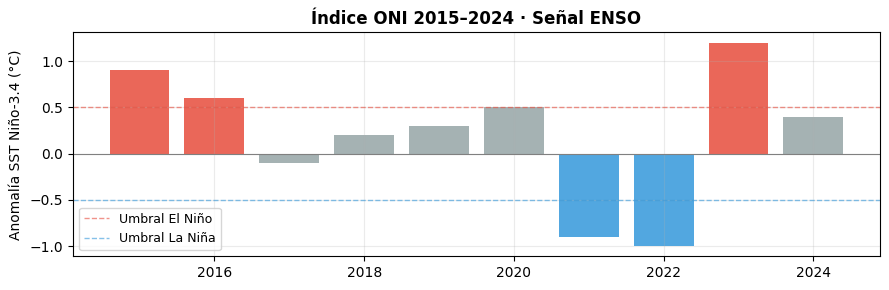

Guardado: oni_2015_2024.png


In [10]:
# ── Índice ONI anual (promedio DJF) ───────────────────────────────────────────
ONI_ANUAL = {
    2015:  0.9,   # El Niño moderado → fuerte
    2016:  0.6,   # Post-El Niño fuerte
    2017: -0.1,   # Neutro
    2018:  0.2,   # Neutro
    2019:  0.3,   # El Niño débil
    2020:  0.5,   # Transición a La Niña
    2021: -0.9,   # La Niña moderada
    2022: -1.0,   # La Niña fuerte (triple dip)
    2023:  1.2,   # El Niño moderado-fuerte
    2024:  0.4,   # Transición
}
df_oni = pd.DataFrame(list(ONI_ANUAL.items()), columns=['year', 'ONI'])

fig, ax = plt.subplots(figsize=(9, 3))
colores = ['#e74c3c' if v > 0.5 else '#3498db' if v < -0.5 else '#95a5a6'
           for v in df_oni['ONI']]
ax.bar(df_oni['year'], df_oni['ONI'], color=colores, alpha=0.85)
ax.axhline( 0.5, color='#e74c3c', lw=1, ls='--', alpha=0.6, label='Umbral El Niño')
ax.axhline(-0.5, color='#3498db', lw=1, ls='--', alpha=0.6, label='Umbral La Niña')
ax.axhline(0, color='gray', lw=0.8)
ax.set_title('Índice ONI 2015–2024 · Señal ENSO', fontweight='bold')
ax.set_ylabel('Anomalía SST Niño-3.4 (°C)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(PATH_MASTER + 'oni_2015_2024.png', dpi=130)
plt.show()
print('Guardado: oni_2015_2024.png')

---
## Consolidación — Dataset Maestro v4

Ejecutar solo cuando las **40 tareas** (A + B1 + B2 + C × 10 años) digan COMPLETED.

Pasos:
1. Carga A + B1 + B2 + C por año
2. Merge por clave espacial (longitud + latitud redondeadas a 4 decimales)
3. Apila los 10 años
4. Merge con ONI
5. Corrige `loss_anual=0` en 2024 (artefacto Hansen → NaN)
6. Guarda CSV completo 2015–2024 y ventana analítica 2019–2024

In [11]:
# ── Consolidación anual A + B1 + B2 + C ───────────────────────────────────────
YEARS = list(range(2015, 2025))

COL_ORDER = [
    'year', 'longitude', 'latitude', 'ONI',
    'sst', 'chlor_a', 't2m_anomaly',
    'loss_anual', 'loss_acum', 'treecover2000', 'gHM', 'fire_count',
    'NDVI', 'EVI', 'LST_day', 'lst_extreme_days',
    'ET', 'precipitation', 'precip_anomaly', 'precip_extreme_days',
    'NO2', 'NO2_source', 'CO', 'CO_source', 'SO2', 'SO2_source'
]

años_ok    = []
años_error = []

for year in YEARS:
    paths = {
        'A':  os.path.join(PATH_DRIVE, f'greenbyte_A_{year}.csv'),
        'B1': os.path.join(PATH_DRIVE, f'greenbyte_B1_{year}.csv'),
        'B2': os.path.join(PATH_DRIVE, f'greenbyte_B2_{year}.csv'),
        'C':  os.path.join(PATH_DRIVE, f'greenbyte_C_{year}.csv'),
    }
    faltantes = [k for k, v in paths.items() if not os.path.exists(v)]
    if faltantes:
        print(f'  {year}: FALTANTE tarea(s) {faltantes}')
        años_error.append(year); continue

    dfs = {k: pd.read_csv(v).replace(-9999, np.nan) for k, v in paths.items()}

    # Limpiar columnas internas de GEE
    for df_tmp in dfs.values():
        df_tmp.drop(columns=[c for c in df_tmp.columns
                              if c in ['system:index', '.geo']],
                    inplace=True, errors='ignore')

    # Clave espacial redondeada a 4 decimales (~11 m de tolerancia)
    for df_tmp in dfs.values():
        df_tmp['_key'] = (df_tmp['longitude'].round(4).astype(str) + '_' +
                          df_tmp['latitude'].round(4).astype(str))

    # Merge encadenado: A ← B1 ← B2 ← C
    merged = dfs['A'].copy()
    for tarea in ['B1', 'B2', 'C']:
        cols_new = [c for c in dfs[tarea].columns
                    if c not in ('longitude', 'latitude', 'year', '_key')]
        merged = merged.merge(dfs[tarea][['_key'] + cols_new],
                              on='_key', how='left')

    merged.drop(columns='_key', inplace=True)

    if len(merged) != len(dfs['A']):
        print(f'  {year}: ADVERTENCIA → {len(merged)} filas (esperado {len(dfs["A"])})')
    else:
        print(f'  {year}: {len(merged):,} puntos · OK')

    años_ok.append(merged)

if not años_ok:
    print('No se consolidó ningún año. Verifica los CSVs en PATH_DRIVE.')
else:
    df_master = pd.concat(años_ok, ignore_index=True)

    # Merge ONI
    df_master = df_master.merge(df_oni, on='year', how='left')

    # CORRECCIÓN: Hansen lossyear máximo = 23 (año 2023).
    # Para 2024, lossyear==24 no existe → loss_anual vale 0 (artefacto).
    # Se reemplaza por NaN para no distorsionar tendencias.
    df_master.loc[df_master['year'] == 2024, 'loss_anual'] = np.nan

    # Etiqueta textual de fuente de gases
    if 'NO2_source' in df_master.columns:
        df_master['NO2_source'] = df_master['NO2_source'].map(
            {1.0: 'S5P', 0.0: 'OMI'})
        df_master['CO_source']  = df_master['CO_source'].map(
            {1.0: 'S5P', 0.0: 'MOPITT'})
        df_master['SO2_source'] = df_master['SO2_source'].map(
            {1.0: 'S5P', 0.0: 'OMI_proxy'})

    # Reordenar columnas
    cols_pres  = [c for c in COL_ORDER if c in df_master.columns]
    cols_extra = [c for c in df_master.columns if c not in cols_pres]
    df_master  = df_master[cols_pres + cols_extra]

    # Guardar dataset completo 2015–2024
    ruta_completo = os.path.join(PATH_MASTER, 'master_greenbyte_v4.csv')
    df_master.to_csv(ruta_completo, index=False)

    # Guardar ventana analítica armonizada 2019–2024
    # Esta es la ventana con cobertura completa de S5P — usar en el EDA
    df_analisis = df_master[df_master['year'].between(2019, 2024)].copy()
    ruta_analisis = os.path.join(PATH_MASTER, 'master_greenbyte_v4_2019_2024.csv')
    df_analisis.to_csv(ruta_analisis, index=False)

    print()
    print('=' * 60)
    print(f'master_greenbyte_v4.csv           → {df_master.shape[0]:,} filas · {df_master.shape[1]} cols')
    print(f'master_greenbyte_v4_2019_2024.csv → {df_analisis.shape[0]:,} filas')
    print(f'Años: {sorted(df_master["year"].unique())}')
    print()
    print('Cobertura por variable (dataset completo):')
    print('-' * 52)
    for col in cols_pres:
        if col in ('year','longitude','latitude',
                   'NO2_source','CO_source','SO2_source'): continue
        pct = df_master[col].notna().mean() * 100
        bar = '█' * int(pct / 5)
        print(f'  {col:22s} {bar:20s} {pct:5.1f}%')
    if años_error:
        print(f'\n  Años con error (relanzar): {años_error}')

  2015: 12,014 puntos · OK
  2016: 12,014 puntos · OK
  2017: 12,014 puntos · OK
  2018: 12,014 puntos · OK
  2019: 12,014 puntos · OK
  2020: 12,014 puntos · OK
  2021: 12,014 puntos · OK
  2022: 12,014 puntos · OK
  2023: 12,014 puntos · OK
  2024: 12,014 puntos · OK

master_greenbyte_v4.csv           → 120,140 filas · 25 cols
master_greenbyte_v4_2019_2024.csv → 72,084 filas
Años: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

Cobertura por variable (dataset completo):
----------------------------------------------------
  ONI                    ████████████████████ 100.0%
  sst                    ██████████            53.3%
  chlor_a                ████████              42.6%
  t2m_anomaly            █████████             49.6%
  loss_anual             ███████               37.6%
  loss_acum              ██████████████████    92.4%
  treecover2000          █████████████

---
## Verificación del dataset v4

In [12]:
# ── Verificación post-consolidación ───────────────────────────────────────────
df = pd.read_csv(os.path.join(PATH_MASTER, 'master_greenbyte_v4.csv'))

print('SHAPE:', df.shape)
print('COLUMNAS:', list(df.columns))

print('\nRANGO GEOGRÁFICO:')
print(f'  lon: {df["longitude"].min():.2f} → {df["longitude"].max():.2f}')
print(f'  lat: {df["latitude"].min():.2f} → {df["latitude"].max():.2f}')

print('\nONI por año:')
print(df.groupby('year')['ONI'].first().to_string())

print('\nFUENTE DE GASES POR AÑO (verificar discontinuidad 2018→2019):')
if 'NO2_source' in df.columns:
    print(df.groupby('year')['NO2_source'].first().to_string())

print('\nLOSS_ANUAL por año (2024 debe ser NaN — artefacto corregido):')
print(df.groupby('year')['loss_anual'].mean().round(5).to_string())

print('\nT2M_ANOMALY por año (positivo = más cálido que ref 1981–2010):')
if 't2m_anomaly' in df.columns:
    print(df.groupby('year')['t2m_anomaly'].mean().round(3).to_string())

print('\nLST_EXTREME_DAYS por año:')
if 'lst_extreme_days' in df.columns:
    print(df.groupby('year')['lst_extreme_days'].mean().round(2).to_string())

SHAPE: (120140, 25)
COLUMNAS: ['year', 'longitude', 'latitude', 'ONI', 'sst', 'chlor_a', 't2m_anomaly', 'loss_anual', 'loss_acum', 'treecover2000', 'gHM', 'fire_count', 'NDVI', 'EVI', 'LST_day', 'ET', 'precipitation', 'precip_anomaly', 'precip_extreme_days', 'NO2', 'NO2_source', 'CO', 'CO_source', 'SO2', 'SO2_source']

RANGO GEOGRÁFICO:
  lon: -118.47 → -86.58
  lat: 14.49 → 33.80

ONI por año:
year
2015    0.9
2016    0.6
2017   -0.1
2018    0.2
2019    0.3
2020    0.5
2021   -0.9
2022   -1.0
2023    1.2
2024    0.4

FUENTE DE GASES POR AÑO (verificar discontinuidad 2018→2019):
year
2015    None
2016    None
2017    None
2018     S5P
2019     S5P
2020     S5P
2021     S5P
2022     S5P
2023     S5P
2024     S5P

LOSS_ANUAL por año (2024 debe ser NaN — artefacto corregido):
year
2015    0.02350
2016    0.03781
2017    0.03604
2018    0.03738
2019    0.03477
2020    0.03400
2021    0.03047
2022    0.02632
2023    0.04202
2024        NaN

T2M_ANOMALY por año (positivo = más cálido que ref

/tmp/ipykernel_5804/2109729703.py:2: DtypeWarning: Columns (20,22,24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(PATH_MASTER, 'master_greenbyte_v4.csv'))


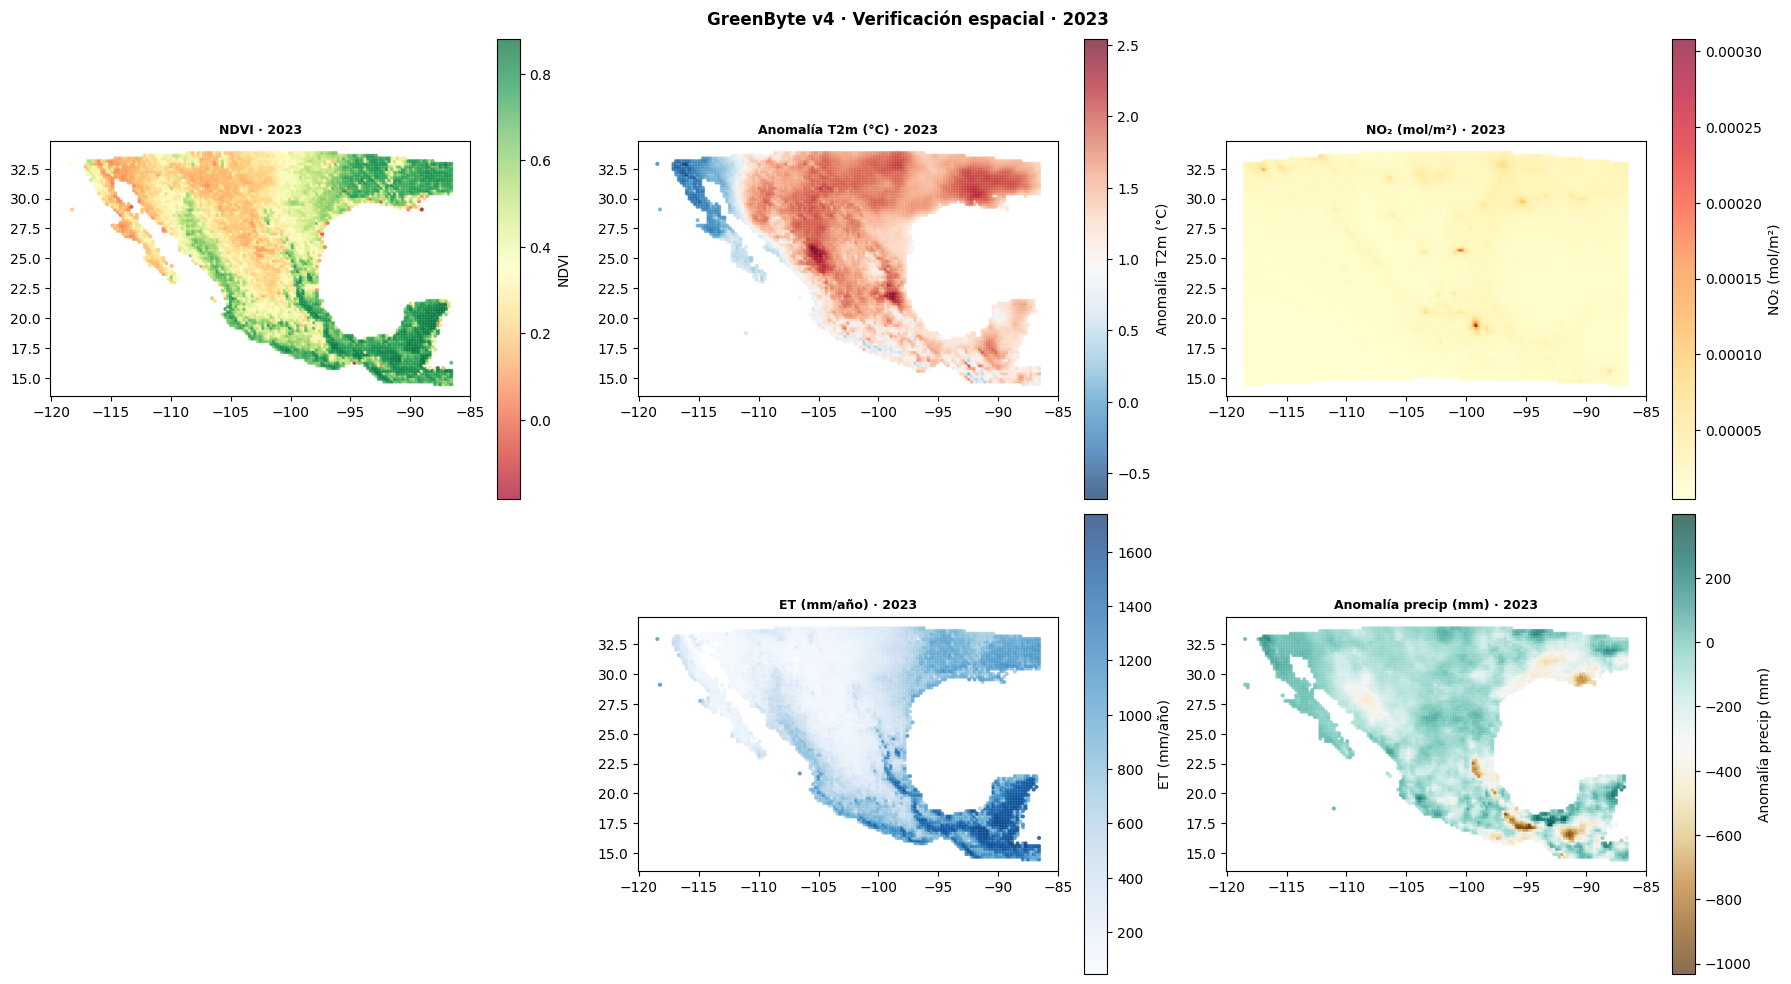

Guardado: verificacion_espacial_v4.png


In [13]:
# ── Verificación espacial: mapas 2023 ─────────────────────────────────────────
df23 = df[df['year'] == 2023]

vars_plot = [
    ('NDVI',              'RdYlGn', 'NDVI'),
    ('t2m_anomaly',       'RdBu_r', 'Anomalía T2m (°C)'),
    ('NO2',               'YlOrRd', 'NO₂ (mol/m²)'),
    ('lst_extreme_days',  'Reds',   'Días calor extremo'),
    ('ET',                'Blues',  'ET (mm/año)'),
    ('precip_anomaly',    'BrBG',   'Anomalía precip (mm)'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (var, cmap, label) in zip(axes, vars_plot):
    if var not in df23.columns:
        ax.set_visible(False); continue
    mask = df23[var].notna()
    sc = ax.scatter(df23.loc[mask, 'longitude'], df23.loc[mask, 'latitude'],
                    c=df23.loc[mask, var], cmap=cmap, s=4, alpha=0.7)
    plt.colorbar(sc, ax=ax, label=label)
    ax.set_title(f'{label} · 2023', fontsize=9, fontweight='bold')
    ax.set_aspect('equal')

plt.suptitle('GreenByte v4 · Verificación espacial · 2023', fontweight='bold')
plt.tight_layout()
plt.savefig(PATH_MASTER + 'verificacion_espacial_v4.png', dpi=130)
plt.show()
print('Guardado: verificacion_espacial_v4.png')

/tmp/ipykernel_5804/3353166498.py:2: DtypeWarning: Columns (20,22,24) have mixed types. Specify dtype option on import or set low_memory=False.
  df_full = pd.read_csv(os.path.join(PATH_MASTER, 'master_greenbyte_v4.csv'))


OLS: SST ~ ONI
  R²      : 0.427 (42.7% varianza SST = señal ENSO)
  β_ONI   : 0.1951
  p-valor : 0.0403

 year  ONI       sst  sst_residual
 2015  0.9 26.188783      0.347762
 2016  0.6 25.912790      0.130302
 2017 -0.1 25.688428      0.042519
 2018  0.2 25.728538      0.024095
 2019  0.3 25.564911     -0.159043
 2020  0.5 25.693194     -0.069782
 2021 -0.9 25.460406     -0.029413
 2022 -1.0 25.499768      0.029459
 2023  1.2 25.674826     -0.224728
 2024  0.4 25.652294     -0.091171


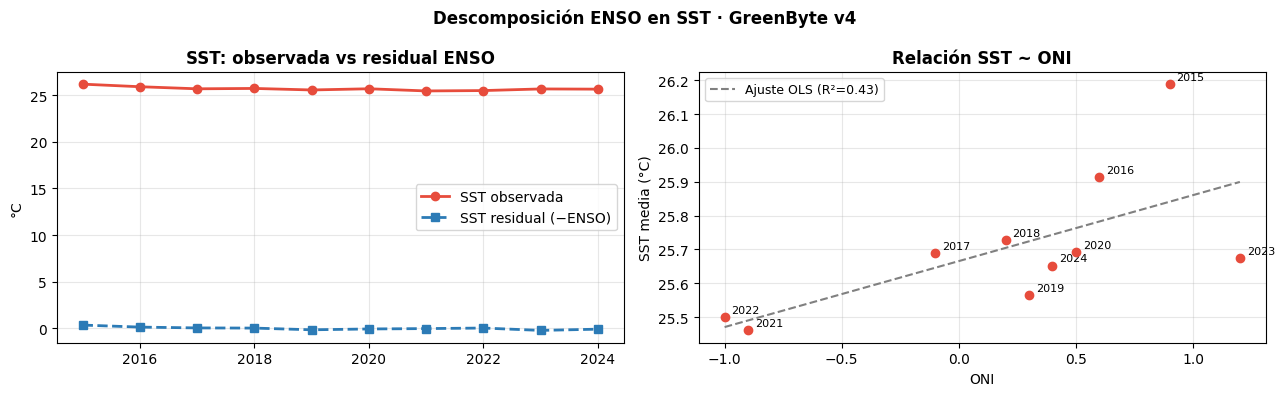

Guardados: sst_enso_descomposicion.png · sst_descomposicion_enso.csv
→ Usar sst_residual (no sst) en el EDA para tendencias climáticas reales.


In [14]:
# ── Descomposición ENSO: SST ~ ONI ─────────────────────────────────────────────
df_full = pd.read_csv(os.path.join(PATH_MASTER, 'master_greenbyte_v4.csv'))
df_sst  = df_full.groupby('year')[['sst', 'ONI']].mean().reset_index()
df_sst  = df_sst.dropna(subset=['sst', 'ONI'])

X     = sm.add_constant(df_sst['ONI'])
model = sm.OLS(df_sst['sst'], X).fit()
df_sst['sst_residual'] = model.resid

print('OLS: SST ~ ONI')
print(f'  R²      : {model.rsquared:.3f} ({model.rsquared*100:.1f}% varianza SST = señal ENSO)')
print(f'  β_ONI   : {model.params["ONI"]:.4f}')
print(f'  p-valor : {model.pvalues["ONI"]:.4f}')
print()
print(df_sst[['year','ONI','sst','sst_residual']].to_string(index=False))

df_sst.to_csv(os.path.join(PATH_MASTER, 'sst_descomposicion_enso.csv'), index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
ax.plot(df_sst['year'], df_sst['sst'],          'o-', lw=2, color='#e74c3c',
        label='SST observada')
ax.plot(df_sst['year'], df_sst['sst_residual'], 's--', lw=2, color='#2c7bb6',
        label='SST residual (−ENSO)')
ax.set_title('SST: observada vs residual ENSO', fontweight='bold')
ax.set_ylabel('°C'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.scatter(df_sst['ONI'], df_sst['sst'], color='#e74c3c', zorder=5)
x_line = np.linspace(df_sst['ONI'].min(), df_sst['ONI'].max(), 50)
y_line = model.params['const'] + model.params['ONI'] * x_line
ax.plot(x_line, y_line, '--', color='gray', lw=1.5,
        label=f'Ajuste OLS (R²={model.rsquared:.2f})')
for _, row in df_sst.iterrows():
    ax.annotate(str(int(row['year'])), (row['ONI'], row['sst']),
                textcoords='offset points', xytext=(5, 3), fontsize=8)
ax.set_xlabel('ONI'); ax.set_ylabel('SST media (°C)')
ax.set_title('Relación SST ~ ONI', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.suptitle('Descomposición ENSO en SST · GreenByte v4', fontweight='bold')
plt.tight_layout()
plt.savefig(PATH_MASTER + 'sst_enso_descomposicion.png', dpi=130)
plt.show()
print('Guardados: sst_enso_descomposicion.png · sst_descomposicion_enso.csv')
print('→ Usar sst_residual (no sst) en el EDA para tendencias climáticas reales.')

---
## Archivos generados por este notebook

| Archivo | Descripción | Usar en EDA |
|---------|-------------|-------------|
| `master_greenbyte_v4.csv` | Dataset completo 2015–2024, 26 variables | Referencia histórica |
| `master_greenbyte_v4_2019_2024.csv` | **Ventana analítica armonizada** 2019–2024 | **Sí — correlaciones, clustering, hotspots** |
| `sst_descomposicion_enso.csv` | SST observada + ONI + sst_residual | Tendencia SST sin ENSO |
| `oni_2015_2024.png` | Señal ENSO por año | Documentación |
| `verificacion_espacial_v4.png` | Mapas 6 variables (2023) | Documentación |
| `sst_enso_descomposicion.png` | SST observada vs residual | Documentación |

### Instrucciones para el EDA v3

1. Cargar `master_greenbyte_v4_2019_2024.csv` para el análisis principal
2. SST: usar `sst_residual` de `sst_descomposicion_enso.csv`
3. Gases: analizar OMI (2015–2018) y S5P (2019–2024) como sub-series **separadas**
4. `loss_anual`: usar solo 2019–2023 (2024 = NaN por diseño)
5. Variables nuevas disponibles para análisis: `t2m_anomaly`, `ET`, `precip_anomaly`, `lst_extreme_days`, `precip_extreme_days`, `fire_count`

---